In [55]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter,zoom
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion,binary_dilation
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
import pickle
import warnings
import seaborn as sns

In [2]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')

behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=100
event='10flies_5sec'
ch_g=2
ch_r=1
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
os.listdir(later_dir)

['behave_dict_total_best.pkl',
 'behave_dict_total_10flies.pkl',
 'lc_glom_masks',
 'behave_dict_total_flat.pkl',
 'individual_supervox_dict.h5',
 'total',
 'flat',
 'inc',
 'behave_dict_total_best_5sec.pkl',
 'figs',
 '10flies_total_dict.pkl',
 'behave_dict_total_new_best_5sec.pkl',
 'behave_dict_total_10flies_5sec.pkl',
 'single_fly_supervox',
 'dec',
 'clustering',
 'non']

In [4]:
total_path = os.path.join(later_dir, 'behave_dict_total_10flies_5sec.pkl')
print("Loading total dict")
with open(total_path, 'rb') as file:
        data = pickle.load(file)

Loading total dict


In [5]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [6]:
data['total'].shape

(314, 146, 91, 50)

In [7]:
behave_dict_z={}
for behavior in data:
    print(behavior)
    signals_total_z=scipy.stats.zscore(data[behavior],axis=-1)[...,14:41]
    behave_dict_z[behavior]=signals_total_z

total
inc
dec
flat


In [8]:
behaviors=np.asarray(list(data.keys()))

In [9]:
behave_dict_z['total'].shape

(314, 146, 91, 27)

In [10]:
%%time
n_clusters=2000
supervox_dict_total=brainsss.make_supervox_dict(behave_dict_z, behaviors, n_clusters,giant_cluster_labels)


total shape: (91, 2000, 27)
inc shape: (91, 2000, 27)
dec shape: (91, 2000, 27)
flat shape: (91, 2000, 27)
CPU times: user 22.5 s, sys: 152 ms, total: 22.7 s
Wall time: 22.7 s


# Put the Supervoxs back into anatomical space

In [11]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
    supervox_brain=supervox_dict_total[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_brain,-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain,cluster_labels=giant_cluster_labels,n_clusters=n_clusters)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

total
(314, 146, 91, 27)
inc
(314, 146, 91, 27)
dec
(314, 146, 91, 27)
flat
(314, 146, 91, 27)
CPU times: user 48.6 s, sys: 1.5 s, total: 50.1 s
Wall time: 50.1 s


In [12]:
fixed = brainsss.load_fda_meanbrain()
brain=behave_dict_z['total']
# brain=full_res_total_clean
# smoothed=gaussian_filter(full_res['total'], sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, behave_dict['total'], np.nan)
masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

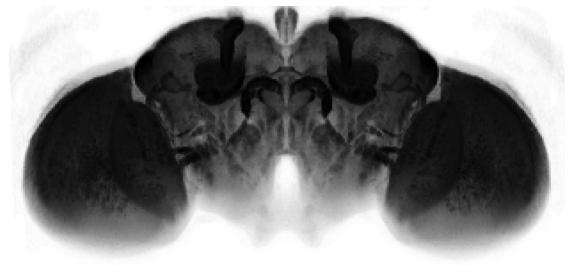

In [13]:
fig = plt.subplots(figsize=(10,10))
plt.imshow(np.max(fixed.numpy(), axis=-1).T, cmap='binary')
plt.axis('off');
# plt.savefig(os.path.join(save_dir,'fda_mean_brain.png'), dpi=300, bbox_inches='tight')

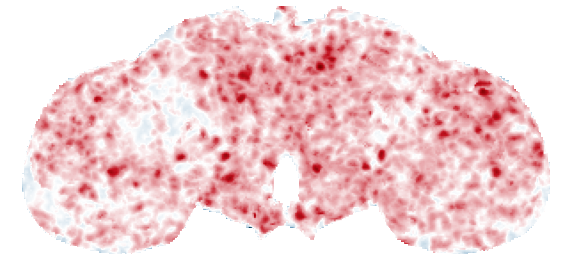

In [14]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]

color_map_color_2=np.asarray(['#5005AF','#9D69D4','#CCB2E7','#FBFAFA','#F6C0DC','#F186BE', '#DB0066' ])

color_map_color_3=np.asarray(['#054A29','#6BAB90','#B5D5C8','#FFFFFF','#E4C5DC','#C98BB9', '#7D5BA6' ])

color_map_color_4=np.asarray(['#1F2041','#4B3F72','#A59FB9','#D2CFDC','#FFFFFF','#C4E7E9','#88CED2','#119DA4', '#19647E' ])

total_colors=color_map_color_3

cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

# cmap=matplotlib.colors.ListedColormap(total_colors)
fig, axs = plt.subplots(figsize=(10,10))
# img=axs.imshow(np.nanmean(np.nanmax(masked[25:30,...], axis=-1), axis=0).T, cmap='Spectral')
img=axs.imshow(np.nanmax(masked[...,3], axis=-1).T, cmap=cmap_personal)
axs.axis('off');
# fig.colorbar(img, ax=axs)
# plt.savefig(os.path.join(save_dir,'STA.png'), dpi=300, bbox_inches='tight')

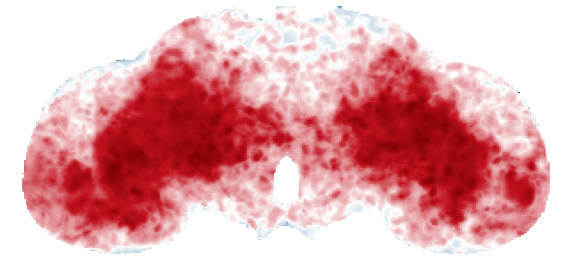

In [15]:
fig, axs = plt.subplots(figsize=(10,10))
# axs.imshow(np.nanmean(np.nanmax(masked[70:85,...], axis=-1), axis=0).T, cmap='Spectral_r')
img=axs.imshow(np.nanmax(masked[...,16], axis=-1).T, cmap=cmap_personal)
axs.axis('off');
# fig.colorbar(img, ax=axs)

In [16]:
vox_traces=masked
# vox_traces_pre=masked[25]
# vox_traces_post=masked[75]
vox_traces_pre=masked[...,3]
vox_traces_post=masked[...,16]
print(vox_traces.shape)
# z,xy,t=vox_traces.shape
# t,x,y,z=vox_traces.shape
x,y,z,t=vox_traces.shape
flattened=vox_traces.reshape(x*y*z*t)
flattened_pre=vox_traces_pre.reshape(x*y*z)
flattened_pre=flattened_pre[~np.isnan(flattened_pre)]
flattened_post=vox_traces_post.reshape(x*y*z)
flattened_post=flattened_post[~np.isnan(flattened_post)]
print(flattened.shape)

(314, 146, 91, 27)
(112638708,)


In [17]:
def mean_edges(flattened):
    mean_line=np.nanmean(flattened)
    std=np.nanstd(flattened)
    neg_edge=mean_line-std
    pos_edge=mean_line+std
    return mean_line, neg_edge, pos_edge

In [18]:
m,n,p=mean_edges(flattened)
mr,nr,pr=mean_edges(flattened_pre)
mo,no,po=mean_edges(flattened_post)

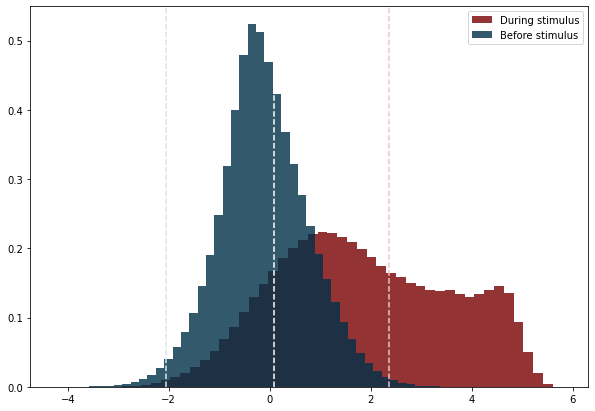

In [19]:
n_bins=100
fig, ax=plt.subplots(figsize=(10,7));
# plt.hist(flattened, bins=n_bins, density=True, color='k', label="Total");
ax.hist(flattened_post, bins=int(n_bins/2), density=True,color='#780000', alpha=0.8, label="During stimulus");
ax.hist(flattened_pre, bins=int(n_bins/2), density=True, color='#003049', alpha=0.8, label="Before stimulus");


ax.axvline(m, ls='--', color='w')
ax.axvline(n*2, ls='--', color='#D9E6EF')
ax.axvline(p*2, ls='--', color='#F0C4C7')
# ax.set_xlim((-0.1,0.2))
ax.legend();
# plt.savefig(os.path.join(save_dir,'supervox_hist.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'supervox_hist.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [20]:
hist_b, edges_b=np.histogram(flattened_pre, bins=int(n_bins/2), density=True)
hist_d, edges_d=np.histogram(flattened_post, bins=int(n_bins/2), density=True)

In [21]:
edges_d.max()

5.798253

In [22]:
b=norm.cdf(hist_b, edges_b[:-1])
d=norm.cdf(hist_d, edges_d[:-1])
print(np.shape(b))

(50,)


In [23]:
Xb=flattened_pre.reshape(-1,1)
Xd=flattened_post.reshape(-1,1)
valb, edgesb=np.histogram(Xb)
vald, edgesd=np.histogram(Xd)
all_edges=[edgesb.max(), edgesb.min(), edgesd.max(), edgesd.min()]
total_max=np.max(all_edges)
total_min=np.min(all_edges)
x = np.linspace(total_min, total_max, 1000)

In [24]:
def make_cdf(X, x, comps):
    # estimate probability density function (pdf)
    model = GaussianMixture(n_components=comps)
    model.fit(X)
    logprob = model.score_samples(x.reshape(-1, 1))
    pdf = np.exp(logprob)
    # derive cumulative distribution function (cdf)
    cdf = np.cumsum(pdf)
    # scale as a probability distribution
    cdf = cdf / np.max(cdf)
    return cdf,pdf

In [25]:
cdfb, pdfb=make_cdf(Xb, x, 5)
cdfd, pdfd=make_cdf(Xd, x, 5)

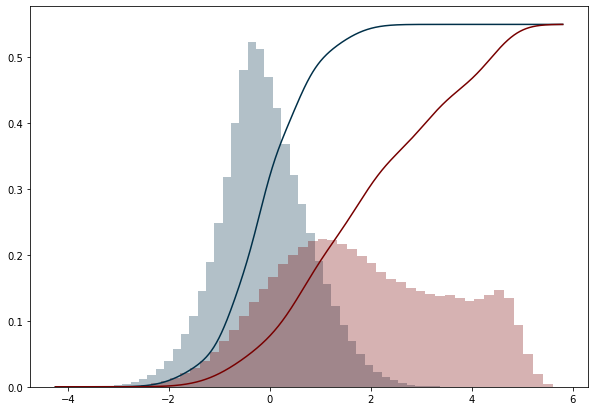

In [26]:
# plot data and pdf  
plt.subplots(figsize=(10,7));
plt.hist(Xb, 50, density=True,color='#003049', histtype='stepfilled', alpha=0.3)
plt.hist(Xd, 50, density=True,color='#780000', histtype='stepfilled', alpha=0.3)
# plt.plot(x, pdfb, '-k', alpha=0.3)
# plt.plot(x, pdfd, '-k', alpha=0.3)
# plot cdf, scaled to the y limits of the above plot
xmin, xmax, ymin, ymax = plt.axis()
plt.plot(x, cdfb * ymax, color='#003049', label="Before stimulus");
plt.plot(x, cdfd * ymax, color='#780000', label="During stimulus");
# plt.savefig(os.path.join(save_dir,'supervox_hist.png'), dpi=300, bbox_inches='tight')
# plt.legend();

In [27]:
KS = scipy.stats.ks_2samp(cdfb, cdfd)
MW = scipy.stats.mannwhitneyu(cdfb, cdfd)
TT = scipy.stats.ttest_ind(cdfb, cdfd)

In [28]:
print(KS)
print(MW)
print(TT)

KstestResult(statistic=0.331, pvalue=6.841548019463371e-49)
MannwhitneyuResult(statistic=342237.0, pvalue=1.2575551515134756e-34)
Ttest_indResult(statistic=10.769560132489923, pvalue=2.492811199583209e-26)


In [29]:
imgs = axs.get_images()
if len(imgs) > 0:
    vmin, vmax = imgs[0].get_clim()

In [30]:
vmax

5.798253

In [31]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape

(1256, 584, 363)

In [32]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')

(1256, 584, 363)


In [129]:
%%time
# brain_pre=np.mean(full_res['total'][25:35,...], axis=0)
# brain_pre=full_res['total'][25,...]
# brain_pre=behave_dict['total'][...,2]
brain_pre=behave_dict_z['total'][...,17]
# brain_pre=np.nan_to_num(full_res_total_clean[...,2])
# brain_post=np.mean(full_res['total'][70:85,...], axis=0)
# brain_post=full_res['total'][75,...]
brain_post=behave_dict_z['total'][...,25]
# brain_post=np.nan_to_num(full_res_total_clean[...,15])
# brain_post=behave_dict['total'][...,25]
# plt.imshow(brain_pre[...,10])
# Calculate the scaling factors
nx,ny,nz=atlas.shape
ox,oy,oz=brain_pre.shape
scale_factors = (nx/ox, ny/oy, nz/oz)
# Resample using zoom with cubic interpolation (order=3)
maps_voxel_high_res_pre = zoom(brain_pre, scale_factors, order=3)
maps_voxel_high_res_post = zoom(brain_post, scale_factors, order=3)

CPU times: user 2min 1s, sys: 1.4 s, total: 2min 3s
Wall time: 2min 3s


In [130]:
maps_voxel_high_res_post.shape

(1256, 584, 363)

In [131]:
no, nr, pr, po

(0.16892457, -0.978912, 0.7620399, 3.5778701)

In [132]:
masked_pre=np.where(anat_high_res>0.1,maps_voxel_high_res_pre, np.nan)
masked_post=np.where(anat_high_res>0.1,maps_voxel_high_res_post, np.nan)

total_masked_pre_max=np.where(masked_pre>(p*2),masked_pre, np.nan)
total_masked_pre_min=np.where(masked_pre<(n*2),masked_pre, np.nan)
total_masked_post_max=np.where(masked_post>(p*2),masked_post, np.nan)
total_masked_post_min=np.where(masked_post<(n*2),masked_post, np.nan)

In [133]:
# Extract the top half of plasma_r colors
# spect_cmap = plt.cm.Spectral
# spect_cmap_r = plt.cm.Spectral_r
# top_half_colors = spect_cmap(np.linspace(0.5, 0.0, 256))  # Only use 0-0.5 range
# bottom_half_colors = spect_cmap_r(np.linspace(0.0, 0.5, 256)) 
# # Create a new colormap
# top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'top_half_spect', top_half_colors)
# bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'bottom_half_spect', bottom_half_colors)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)


# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

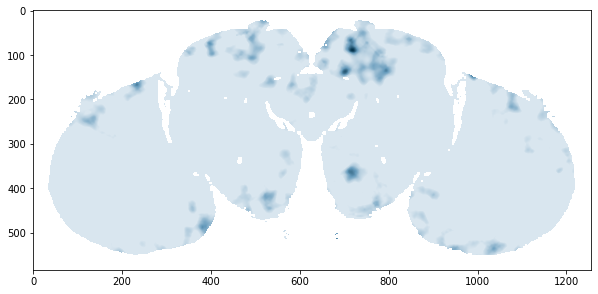

In [134]:
plt.figure(figsize=(10,10))
plt.imshow(total_masked_pre_min[...,200].T, vmax=0.05, cmap='bottom_half_spect')
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(final)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


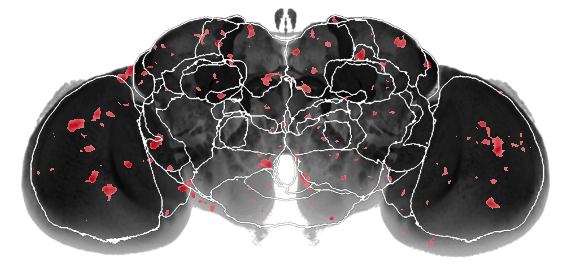

In [135]:
z=250
edges = cv2.Canny(np.max(atlas_int,axis=-1),1,1)
edges = binary_dilation(edges, iterations=1)
edges = scipy.ndimage.median_filter(edges,2)
edges_ = np.repeat(edges.astype('int')[:,:,np.newaxis],repeats=4,axis=-1) ### copy into rgba channels to make white
plt.figure(figsize=(10,10))
plt.imshow(np.max(anat_high_res, axis=-1).T,cmap='gray_r');
plt.imshow(np.nanmax(total_masked_post_max, axis=-1).T,vmax=5, vmin=1,cmap='top_half_spect');
# plt.imshow(np.nanmin(total_masked_pre_min, axis=-1).T,cmap='bottom_half_spect');
plt.imshow(np.swapaxes(edges_,0,1)*10000);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'total_overlay_15_min.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'total_overlay_t4.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [111]:
p

1.1770141

In [113]:
np.nanmax(total_masked_post_max)

5.803512

In [40]:
max_count=np.count_nonzero(~np.isnan(total_masked_pre_max))
total_count=np.count_nonzero(~np.isnan(masked_post))
percent=(max_count/total_count)*100

In [41]:
percent

0.35912260353427866

In [42]:
red_vals=np.where(masked_pre>p,masked_pre, np.nan)
red_count=np.count_nonzero(~np.isnan(red_vals))
total_count=np.count_nonzero(~np.isnan(masked_post))
percent_red=(red_count/total_count)*100

In [43]:
percent_red

7.081630463745747

In [44]:
roi_atlas = brainsss.load_roi_atlas()

In [45]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [46]:
def extract_roi_signal_traces(roi_ids, roi_masks, warps, hemi, signal_type):
    t0 = time.time()
    roi_time_avgs = []
    for roi in roi_ids[hemi]:
        mask = roi_masks[roi]
        masked_data = warps[:,:,:,:]*mask[np.newaxis,:,:,:] #note z-flip
        if signal_type == 'max':
            roi_time_avg = np.max(masked_data,axis=(1,2,3))
        elif signal_type == 'mean':
            roi_time_avg = np.mean(masked_data,axis=(1,2,3))
        roi_time_avgs.append(roi_time_avg)
    print(time.time()-t0)
    return np.asarray(roi_time_avgs)

In [47]:
# %%time
# brain=full_res['total']
# t=np.shape(brain)[0]
# explosions = []
# for tp in range(t):
#     input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
#     data_to_plot = brain[tp][:,:,::-1]
#     vmax = 0.08 #this was 0.5 for STA <------------
#     explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
#                                                         roi_masks,
#                                                         roi_contours,
#                                                         data_to_plot,
#                                                         input_canvas,
#                                                         vmax=vmax,
#                                                         cmap='PuOr', diverging=True)#'hot')
#     explosions.append(explosion_map)

In [48]:
behave_dict_z['total'].shape

(314, 146, 91, 27)

In [76]:
brain=np.moveaxis(behave_dict_z['total'],-1,0)
# brain=np.moveaxis(np.nan_to_num(full_res_total_clean),-1,0)
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[16][:,:,::-1]
vmax = 5 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

(-0.5, 499.5, 329.5, -0.5)

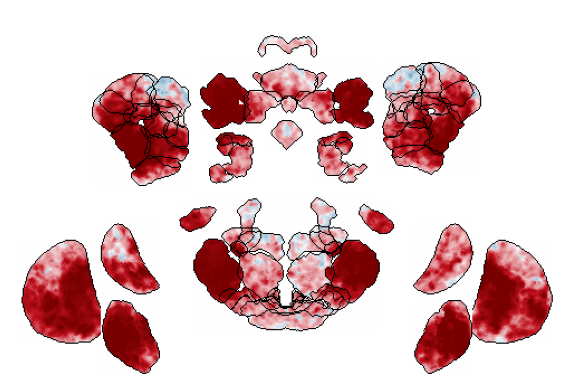

In [77]:
save_dir=os.path.join(later_dir,'figs')
plt.subplots(figsize=(10,10))
# plt.imshow(explosions[40][170:,:]) #this was made with cmap=hot
plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')
# plt.savefig(os.path.join(save_dir,'explode_15.png'), dpi=300, bbox_inches='tight')

In [51]:
%%time

total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
#             print(np.shape(STA))
            masked_roi=[STA[...,i][roi_mask] for i in range(np.shape(STA)[-1])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi

CPU times: user 9.35 s, sys: 310 ms, total: 9.66 s
Wall time: 9.66 s


In [52]:
vis=['PVLP', 'AVLP', 'AOTU', 'MED', 'LO', 'LP']
anat_avgs_vis={}
anat_avgs_novis={}
for behavior in total_vox_sorted:
    bbrain=total_vox_sorted[behavior]
    anat_avgs_vis[behavior]={}
    anat_avgs_novis[behavior]={}
    for anat in bbrain:
        n,t=np.shape(bbrain[anat])
        if anat in vis:
            anat_avgs_vis[behavior][anat] = gaussian_filter1d(np.mean(bbrain[anat], axis=0), sigma=1)
        else:
            anat_avgs_novis[behavior][anat] = gaussian_filter1d(np.mean(bbrain[anat], axis=0), sigma=1)#/(np.std(bbrain[anat], axis=0)/np.sqrt(n))

In [72]:
np.shape(list(anat_avgs_vis['total'].values()))

(6, 27)

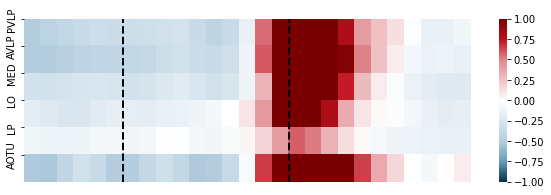

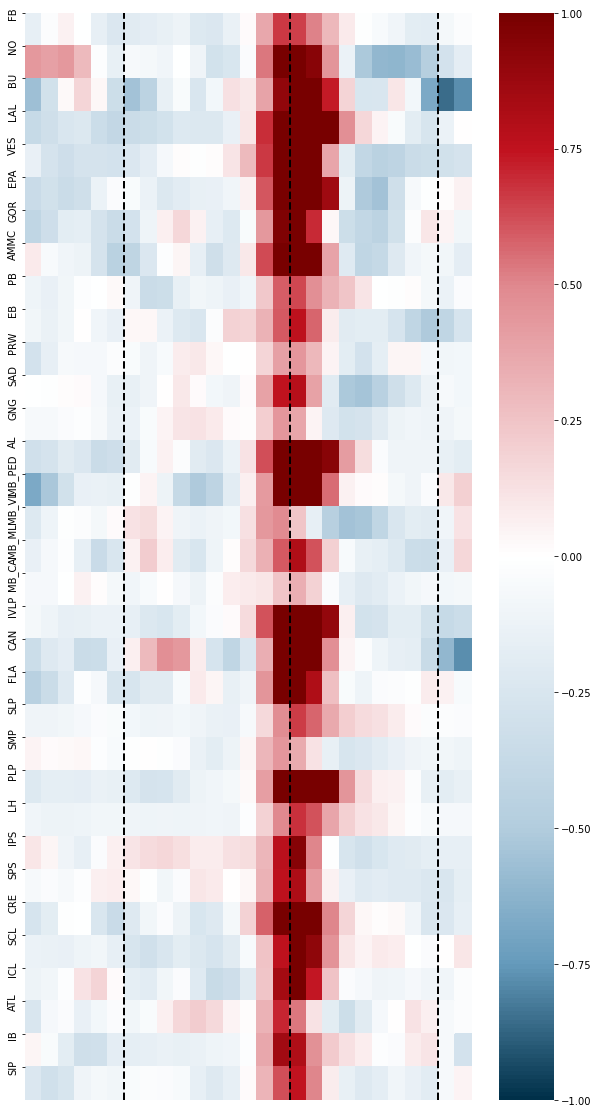

In [73]:
avg_behave=anat_avgs_vis['total']
vmax=1
vmin=-1
fig,axs = plt.subplots(figsize=(10,3))
avg=sns.heatmap(list(avg_behave.values()), vmax=vmax, vmin=vmin, cmap=cmap_personal)
axs.axvline(x=6, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=16, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.set_yticks(np.arange(len(list(avg_behave.keys()))))
axs.set_yticklabels(list(avg_behave.keys()))
axs.set_xticks([])

# fig.colorbar(avg)

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
        
plt.show()

avg_behave=anat_avgs_novis['total']
vmax=1
vmin=-1
fig,axs = plt.subplots(figsize=(10,20))
avg=sns.heatmap(list(avg_behave.values()), vmax=vmax, vmin=vmin, cmap=cmap_personal)
axs.axvline(x=6, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=16, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.set_yticks(np.arange(len(list(avg_behave.keys()))))
axs.set_yticklabels(list(avg_behave.keys()))
axs.axvline(x=25, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.set_xticks([])

# fig.colorbar(avg)

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{step_size}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
        
plt.show()